In [ ]:
# Importing dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from category_encoders import TargetEncoder
from sklearn.preprocessing import OneHotEncoder
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings("ignore")

Reading the dataset

In [ ]:

df = pd.read_csv("D:/Python programming/Projects/Credit-Card-Default-Prediction/dataset/amex_credit_card.csv")

In [ ]:
df.sample(5)

,customer_id,name,age,gender,owns_car,owns_house,no_of_children,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,default_in_last_6months,credit_card_default
380,CST_108664,Grant McCool,31,F,N,N,1.0,153247.53,2994.0,Laborers,2.0,1.0,20741.00,26141.86,94,778.0,0,0,0
14489,CST_106771,Lynnley Browning,25,F,N,Y,0.0,190982.20,365243.0,Unknown,1.0,0.0,26460.24,29762.99,23,700.0,0,0,0
625,CST_121520,Leila Abboud,31,M,N,Y,0.0,123502.21,583.0,Security staff,1.0,0.0,8301.74,15712.58,51,704.0,0,0,0
15734,CST_103641,Carlos Ruano,27,F,Y,Y,0.0,100132.13,1670.0,Unknown,2.0,0.0,31976.74,33925.36,77,833.0,0,0,0
21406,CST_160704,Hirschler,29,M,Y,N,2.0,165903.11,2657.0,Drivers,3.0,0.0,6554.61,26206.83,31,838.0,0,0,0


This dataset contains information on default payments, demographic factors, credit data, history of payment, and bill statements of credit card clients in Taiwan from April 2005 to September 2005.

In [ ]:
df.shape

(45528, 19)

In [ ]:
for column in df.columns.tolist():
    print(column)


customer_id
name
age
gender
owns_car
owns_house
no_of_children
net_yearly_income
no_of_days_employed
occupation_type
total_family_members
migrant_worker
yearly_debt_payments
credit_limit
credit_limit_used(%)
credit_score
prev_defaults
default_in_last_6months
credit_card_default


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45528 entries, 0 to 45527
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              45528 non-null  str    
 1   name                     45528 non-null  str    
 2   age                      45528 non-null  int64  
 3   gender                   45528 non-null  str    
 4   owns_car                 44981 non-null  str    
 5   owns_house               45528 non-null  str    
 6   no_of_children           44754 non-null  float64
 7   net_yearly_income        45528 non-null  float64
 8   no_of_days_employed      45065 non-null  float64
 9   occupation_type          45528 non-null  str    
 10  total_family_members     45445 non-null  float64
 11  migrant_worker           45441 non-null  float64
 12  yearly_debt_payments     45433 non-null  float64
 13  credit_limit             45528 non-null  float64
 14  credit_limit_used(%)     45528 no

# Data cleaning & Feature engineering

Checking for duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

Checking consistency of categorical values

In [ ]:
df.drop(columns=["customer_id","name"],inplace=True) # First removing customer ID and name because they are only identity columns,
cat_col = df.select_dtypes(include=["str"]).columns.tolist() + ["migrant_worker","prev_defaults","default_in_last_6months",
                                                                "total_family_members","no_of_children"]
target = "credit_card_default"
num_col = [col for col in df.columns if col not in cat_col]
num_col.remove(target)

In [ ]:
df[target].unique()

array([1, 0])

In [ ]:
for col in cat_col:
    print(f"{col}: {df[col].unique().tolist()}\n")

gender: ['F', 'M', 'XNA']

owns_car: ['N', 'Y', nan]

owns_house: ['Y', 'N']

occupation_type: ['Unknown', 'Laborers', 'Core staff', 'Accountants', 'High skill tech staff', 'Sales staff', 'Managers', 'Drivers', 'Medicine staff', 'Cleaning staff', 'HR staff', 'Security staff', 'Cooking staff', 'Waiters/barmen staff', 'Low-skill Laborers', 'Private service staff', 'Secretaries', 'Realty agents', 'IT staff']

migrant_worker: [1.0, 0.0, nan]

prev_defaults: [2, 0, 1]

default_in_last_6months: [1, 0]

total_family_members: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, nan, 7.0, 8.0, 9.0, 10.0]

no_of_children: [0.0, 1.0, 2.0, nan, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]



Checking for null values

In [ ]:
df.gender.value_counts()

gender
F      29957
M      15570
XNA        1
Name: count, dtype: int64

In [ ]:
df = df[df["gender"]!="XNA"] # Removing unknown gender entry

In [ ]:
df.isnull().sum()

age                          0
gender                       0
owns_car                   547
owns_house                   0
no_of_children             774
net_yearly_income            0
no_of_days_employed        463
occupation_type              0
total_family_members        83
migrant_worker              87
yearly_debt_payments        95
credit_limit                 0
credit_limit_used(%)         0
credit_score                 8
prev_defaults                0
default_in_last_6months      0
credit_card_default          0
dtype: int64

In [ ]:
display((df.isnull().mean()*100).sort_values(ascending=False)[0:7])

no_of_children          1.700090
owns_car                1.201485
no_of_days_employed     1.016979
yearly_debt_payments    0.208667
migrant_worker          0.191095
total_family_members    0.182309
credit_score            0.017572
dtype: float64

In [ ]:
# Dropping rows with missing values from columns with very few missing values
df.dropna(subset=["yearly_debt_payments","migrant_worker","total_family_members","credit_score"],inplace=True)
df.shape

(45255, 17)

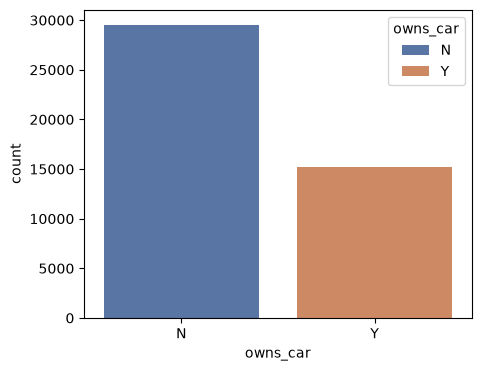

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(data=df,x="owns_car",palette="deep",hue="owns_car")
plt.show()

In [ ]:
df["owns_car"] = df["owns_car"].fillna(df["owns_car"].mode()[0]) # mode imputation

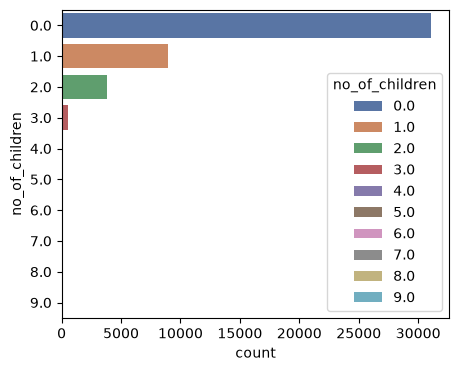

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(data=df,y="no_of_children",palette="deep",hue="no_of_children")
plt.show()

KNN Imputer is used because the number of children is closely related to other features like age, marital status, and family size. By using nearest neighbors, the imputed values are influenced by similar individuals in the dataset, leading to more realistic estimates than simply filling with mean or mode.


In [ ]:
imputer = KNNImputer(n_neighbors=5)
df[["no_of_children"]] = imputer.fit_transform(df[["no_of_children"]])
df["no_of_children"] = df["no_of_children"].round().astype(int)

In [ ]:
display(pd.DataFrame(df["no_of_days_employed"].describe()).T)

,count,mean,std,min,25%,50%,75%,max
no_of_days_employed,44794.0,67582.464973,139301.251385,2.0,936.0,2224.0,5813.5,365252.0


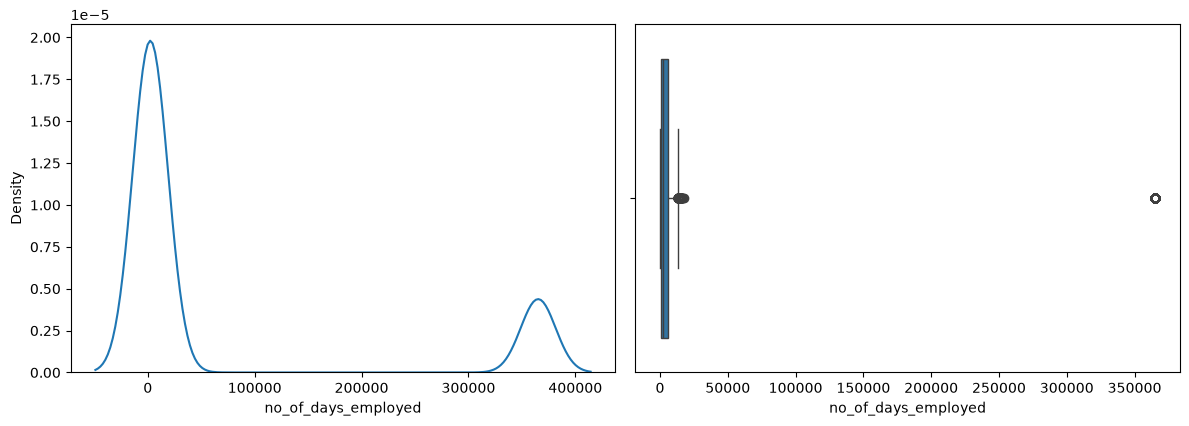

In [ ]:
plt.figure(figsize=(12,4*2))
plt.subplot(2,2,1)
sns.kdeplot(data=df,x="no_of_days_employed")
plt.subplot(2,2,2)
sns.boxplot(data=df,x="no_of_days_employed")
plt.tight_layout()
plt.show()

In [ ]:
df[df["no_of_days_employed"]>((df["age"]-15)*365)]["no_of_days_employed"].head(10)

3      11941.0
8      11551.0
12    365247.0
16      8058.0
23      4057.0
27     10188.0
28      3978.0
29    365251.0
32    365247.0
45    365241.0
Name: no_of_days_employed, dtype: float64

In [ ]:
df[df["no_of_days_employed"]>((df["age"]-15)*365)]["no_of_days_employed"].shape

(10345,)

In [ ]:
df[df["no_of_days_employed"]>300000].shape

(8046, 17)

In [ ]:
df[df["no_of_days_employed"]>300000]["no_of_days_employed"].head()

12    365247.0
29    365251.0
32    365247.0
45    365241.0
48    365240.0
Name: no_of_days_employed, dtype: float64

The invalid no_of_days_employed values are simply placeholders indicating that the customer is unemployed. Therefore, these values can be treated as MNAR (Missing Not At Random). We will replace both the invalid placeholder values and the missing values with 0, and create a new binary feature called is_employed to indicate whether a customer is employed.

In [ ]:
df.loc[df["no_of_days_employed"]>((df["age"]-15)*365),"no_of_days_employed"] = 0
df["no_of_days_employed"] = df["no_of_days_employed"].fillna(0)

In [ ]:
df.no_of_days_employed.head()

array([  612.,  2771.,   204., ..., 10398., 10009.,  5372.], shape=(6677,))

In [ ]:
df["is_employed"] = (df["no_of_days_employed"] != 0).astype(int) # creating another feature

In [ ]:
df["years_experienced"] = df["no_of_days_employed"]/365
df["years_experienced"] = df["years_experienced"].round(2)

In [ ]:
df.isnull().sum()

age                        0
gender                     0
owns_car                   0
owns_house                 0
no_of_children             0
net_yearly_income          0
no_of_days_employed        0
occupation_type            0
total_family_members       0
migrant_worker             0
yearly_debt_payments       0
credit_limit               0
credit_limit_used(%)       0
credit_score               0
prev_defaults              0
default_in_last_6months    0
credit_card_default        0
is_employed                0
years_experienced          0
dtype: int64

# EDA

In [ ]:
cat_col = df.select_dtypes(include=["str"]).columns.tolist() + ["migrant_worker","prev_defaults","default_in_last_6months",
                                                                "total_family_members","no_of_children","is_employed"]
target = "credit_card_default"
num_col = [col for col in df.columns if col not in cat_col]
num_col.remove(target)

target

credit_card_default,0,1
proportion,91.87935,8.12065


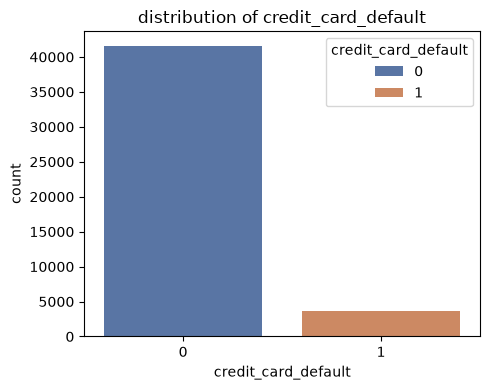

In [ ]:
display(pd.DataFrame(df[target].value_counts(normalize=True)*100).T)
plt.figure(figsize=(5,4))
sns.countplot(data=df, x=target, palette="deep",hue=target)
plt.title(f"distribution of {target}")
plt.tight_layout()
plt.show()

### Observations

- **Target Variable (credit_card_default):** The target is **highly imbalanced**, with **91.88% non-defaulters (Class 0)** and **8.12% defaulters (Class 1)**.

- The significant class imbalance indicates that **accuracy alone is not an appropriate evaluation metric**.

- Model performance should primarily be evaluated using **ROC-AUC, Precision, Recall, F1-score, and Precision-Recall AUC**.

- Since the minority class is underrepresented, **class imbalance handling** (e.g., class weights or SMOTE on the training data only) should be considered during model training.

categorical features:


gender,F,M
proportion,65.802674,34.197326


owns_car,N,Y
proportion,66.498729,33.501271


owns_house,Y,N
proportion,69.499503,30.500497


occupation_type,Unknown,Laborers,Sales staff,Core staff,Managers,Drivers,High skill tech staff,Accountants,Medicine staff,Security staff,Cooking staff,Cleaning staff,Private service staff,Low-skill Laborers,Waiters/barmen staff,Secretaries,Realty agents,HR staff,IT staff
proportion,31.393216,17.865429,10.348028,8.940449,6.964976,6.039112,3.683571,3.24384,2.8019,2.260524,1.982101,1.465031,0.855154,0.73804,0.44636,0.435311,0.22097,0.172357,0.143631


migrant_worker,0.0,1.0
proportion,82.092586,17.907414


prev_defaults,0,1,2
proportion,94.572975,4.781792,0.645233


default_in_last_6months,0,1
proportion,94.941995,5.058005


total_family_members,2.0,1.0,3.0,4.0,5.0,6.0,7.0,8.0,10.0,9.0
proportion,51.596509,21.823003,17.191471,7.981439,1.237432,0.125953,0.024307,0.013258,0.004419,0.00221


no_of_children,0,1,2,3,4,5,6,7,8,9
proportion,70.317092,19.741465,8.483041,1.279417,0.132582,0.026516,0.013258,0.00221,0.00221,0.00221


is_employed,1,0
proportion,76.121975,23.878025


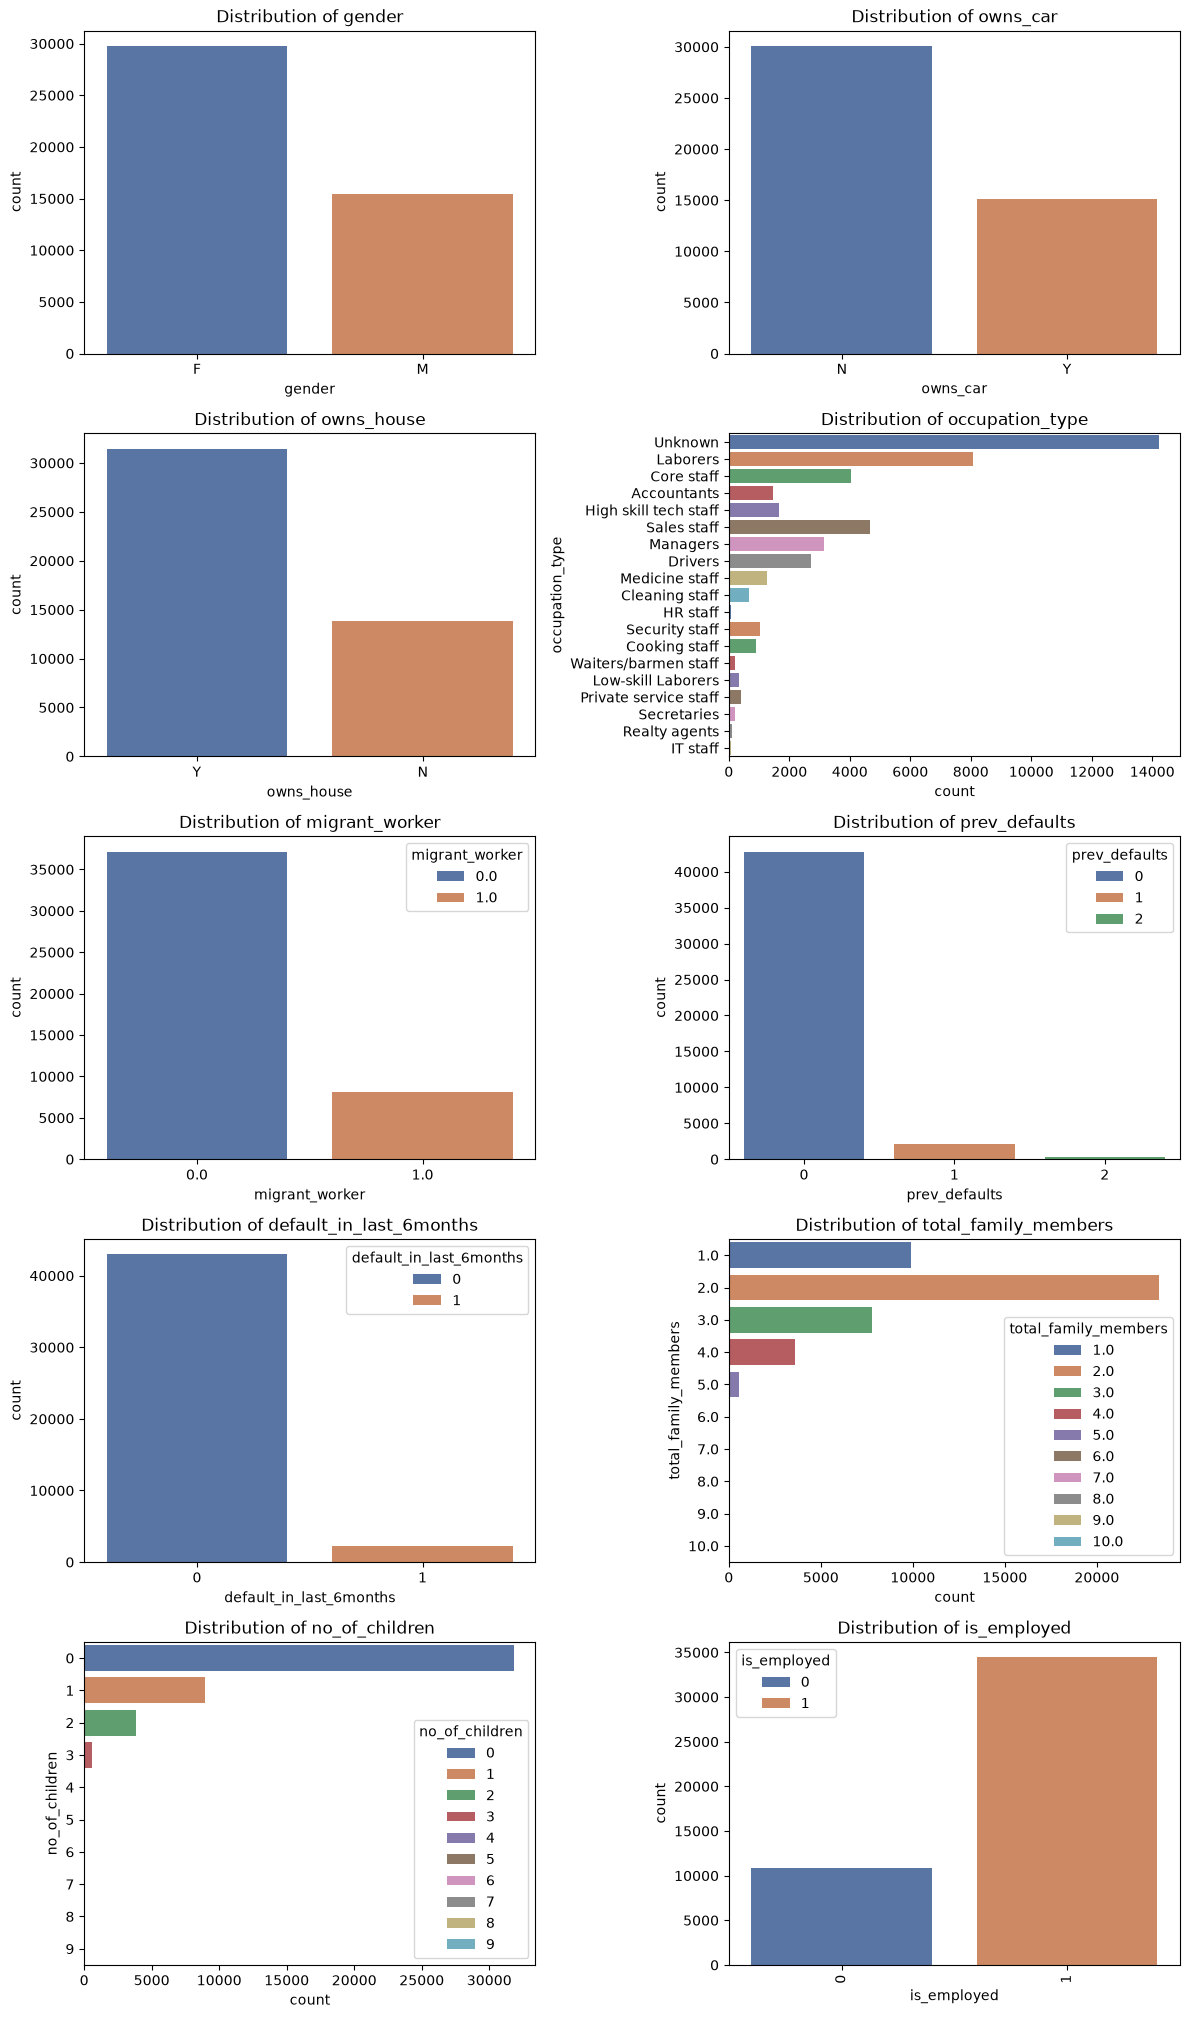

In [ ]:
plt.figure(figsize=(12,4*len(cat_col)))
for i, col in enumerate(cat_col):
    value_counts = pd.DataFrame(df[col].value_counts(normalize=True)*100)
    display(value_counts.T)
    if len(df[col].unique())>8:
        plt.subplot(len(cat_col),2,i+1)
        sns.countplot(data = df, y=col, palette="deep",hue=col)
        plt.title(f"Distribution of {col}")
    else:
        plt.subplot(len(cat_col),2,i+1)
        sns.countplot(data = df, x=col, palette="deep",hue=col)
        plt.title(f"Distribution of {col}")    
plt.xticks(rotation=90)    
plt.tight_layout()
plt.show()


### Observations

- **Gender:** Majority of customers are **Female (~65.8%)**. The single `XNA` entry is an invalid category and should be removed.

- **Owns Car:** Around **66.1%** of customers do not own a car. Since only **1.2%** values are missing, **mode imputation** is appropriate.

- **Owns House:** Nearly **69.5%** of customers own a house, indicating a moderately imbalanced distribution.

- **Occupation Type:** The feature contains **19 categories** with a highly imbalanced distribution. **'Unknown' (~31.4%)** is the largest category and should be retained as a valid category.

- **Migrant Worker:** Around **82.1%** of customers are non-migrant workers, resulting in an imbalanced distribution.

- **Previous Defaults:** Nearly **94.6%** of customers have **no previous defaults**, while very few have one or more previous defaults.

- **Default in Last 6 Months:** Approximately **94.9%** of customers have **no default in the last six months**, making this a highly imbalanced binary feature.

- **Total Family Members:** Most customers belong to **small families (1–3 members)**, with **2-member families (~51.6%)** being the most common.

- **Number of Children:** Around **69.8%** of customers have **no children**, with the frequency decreasing sharply as the number of children increases. Since only **1.7%** values are missing, **mode imputation** is appropriate.

Numerical features

,count,mean,std,min,25%,50%,75%,max
age,45255.0,38.991846,9.543329,23.0,31.0,39.0,47.0,55.0


,count,mean,std,min,25%,50%,75%,max
net_yearly_income,45255.0,200757.848737,671045.643104,27170.61,126367.795,171733.63,240776.425,1.407590e+08


,count,mean,std,min,25%,50%,75%,max
no_of_days_employed,45255.0,1576.437675,1864.321118,0.0,120.0,994.0,2344.0,14219.0


,count,mean,std,min,25%,50%,75%,max
yearly_debt_payments,45255.0,31806.880774,17274.540124,2237.47,19234.89,29093.39,40575.07,328112.86


,count,mean,std,min,25%,50%,75%,max
credit_limit,45255.0,43566.568569,149220.477084,4003.14,23975.905,35692.01,53441.415,31129970.49


,count,mean,std,min,25%,50%,75%,max
credit_limit_used(%),45255.0,52.261452,29.382179,0.0,27.0,54.0,79.0,99.0


,count,mean,std,min,25%,50%,75%,max
credit_score,45255.0,782.844746,100.6366,500.0,704.0,786.0,867.0,949.0


,count,mean,std,min,25%,50%,75%,max
years_experienced,45255.0,4.31903,5.107735,0.0,0.33,2.72,6.42,38.96


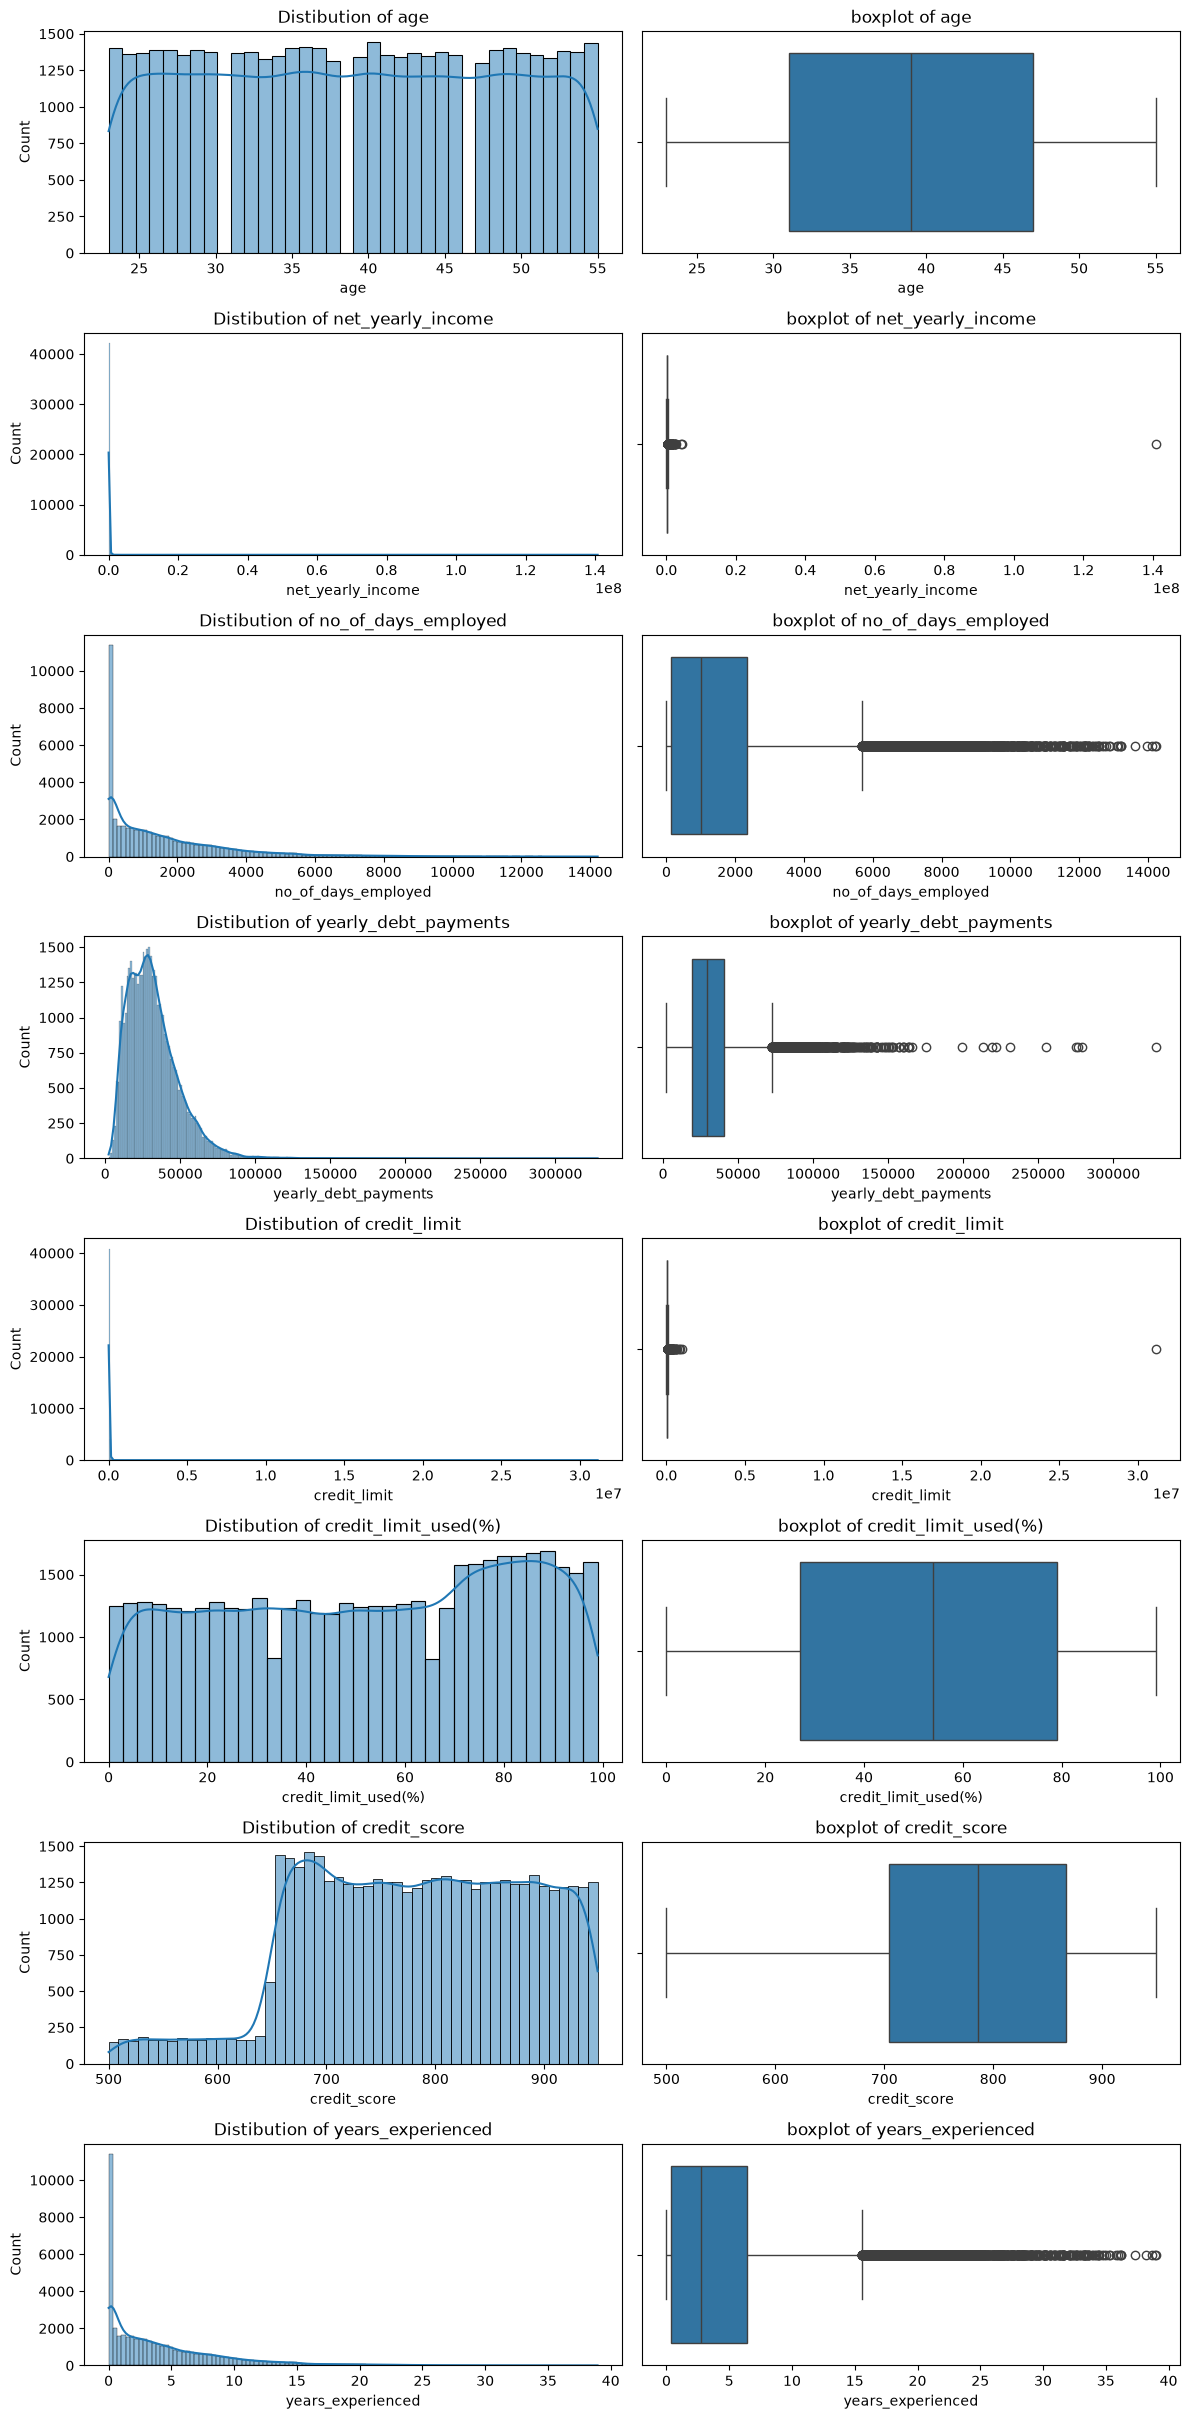

In [ ]:
plt.figure(figsize=(12,6*len(num_col)))
for i, col in enumerate(num_col):
    display((pd.DataFrame(df[col].describe())).T)
    plt.subplot(2*len(num_col),2,(2*i)+1)
    sns.histplot(data=df,x=col, kde=True)
    plt.title(f"Distibution of {col}")
    plt.subplot(2*len(num_col),2,2*(i+1))
    sns.boxplot(data=df, x=col,)
    plt.title(f"boxplot of {col}")
plt.tight_layout()
plt.show()

In [ ]:
# Checking for skewness
df[num_col].skew()

age                       0.004408
net_yearly_income       203.110952
no_of_days_employed       1.896891
yearly_debt_payments      1.723041
credit_limit            199.834587
credit_limit_used(%)     -0.128858
credit_score             -0.302997
years_experienced         1.896885
dtype: float64

### Observations

- **Age:** The age distribution is nearly uniform between **23 and 55 years**, with no significant outliers.

- **Net Yearly Income:** The distribution is **highly right-skewed** with several extreme outliers. A **log transformation** may be applied, while outliers should be retained as they may represent genuine high-income customers.

- **Number of Days Employed:** The feature is **highly right-skewed** with an unusually large maximum value (**365252 days**), indicating a possible special placeholder value. Since **1.02%** values are missing, **median imputation** is appropriate.

- **Yearly Debt Payments:** The distribution is **positively skewed** with several high-value outliers. A **log transformation** is recommended, while the outliers should be retained.

- **Credit Limit:** The feature is **heavily right-skewed** with extreme outliers. A **log transformation** may be applied, while retaining the outliers.

- **Credit Limit Used (%):** The values are bounded between **0 and 99%**, with no noticeable outliers.

- **Credit Score:** Credit scores range from **500 to 949** with no missing values or outliers. The distribution is reasonably balanced.

In [ ]:
skewed_col = ["net_yearly_income","yearly_debt_payments","credit_limit"]
df[["log_net_yearly_income","log_yearly_debt_payments","log_credit_limit"]]=np.log1p(df[skewed_col]) # Applying transformation on highly skewed features

In [ ]:
df[num_col].skew()

age                       0.004408
net_yearly_income       203.110952
no_of_days_employed       1.896891
yearly_debt_payments      1.723041
credit_limit            199.834587
credit_limit_used(%)     -0.128858
credit_score             -0.302997
years_experienced         1.896885
dtype: float64

target VS Categorical features

gender,F,M
credit_card_default,,
0,93.008496,89.706643
1,6.991504,10.293357


owns_car,N,Y
credit_card_default,,
0,91.549811,92.533474
1,8.450189,7.466526


owns_house,N,Y
credit_card_default,,
0,91.755415,91.93374
1,8.244585,8.06626


occupation_type,Accountants,Cleaning staff,Cooking staff,Core staff,Drivers,HR staff,High skill tech staff,IT staff,Laborers,Low-skill Laborers,Managers,Medicine staff,Private service staff,Realty agents,Sales staff,Secretaries,Security staff,Unknown,Waiters/barmen staff
credit_card_default,,,,,,,,,,,,,,,,,,,
0,94.686649,89.74359,88.740245,94.018784,88.291255,91.025641,93.761248,96.923077,89.511441,84.131737,93.274112,92.192429,92.50646,90.0,90.284006,95.939086,89.638319,93.580629,89.60396
1,5.313351,10.25641,11.259755,5.981216,11.708745,8.974359,6.238752,3.076923,10.488559,15.868263,6.725888,7.807571,7.49354,10.0,9.715994,4.060914,10.361681,6.419371,10.39604


migrant_worker,0.0,1.0
credit_card_default,,
0,92.312455,89.89388
1,7.687545,10.10612


prev_defaults,0,1,2
credit_card_default,,,
0,97.151803,0.0,0.0
1,2.848197,100.0,100.0


default_in_last_6months,0,1
credit_card_default,,
0,96.774194,0.0
1,3.225806,100.0


total_family_members,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
credit_card_default,,,,,,,,,,
0,91.555286,92.436831,91.002571,91.334441,91.428571,82.45614,72.727273,100.0,100.0,50.0
1,8.444714,7.563169,8.997429,8.665559,8.571429,17.54386,27.272727,0.0,0.0,50.0


no_of_children,0,1,2,3,4,5,6,7,8,9
credit_card_default,,,,,,,,,,
0,92.338634,90.653683,91.195624,91.537133,81.666667,75.0,100.0,100.0,100.0,0.0
1,7.661366,9.346317,8.804376,8.462867,18.333333,25.0,0.0,0.0,0.0,100.0


is_employed,0,1
credit_card_default,,
0,94.706644,90.992482
1,5.293356,9.007518


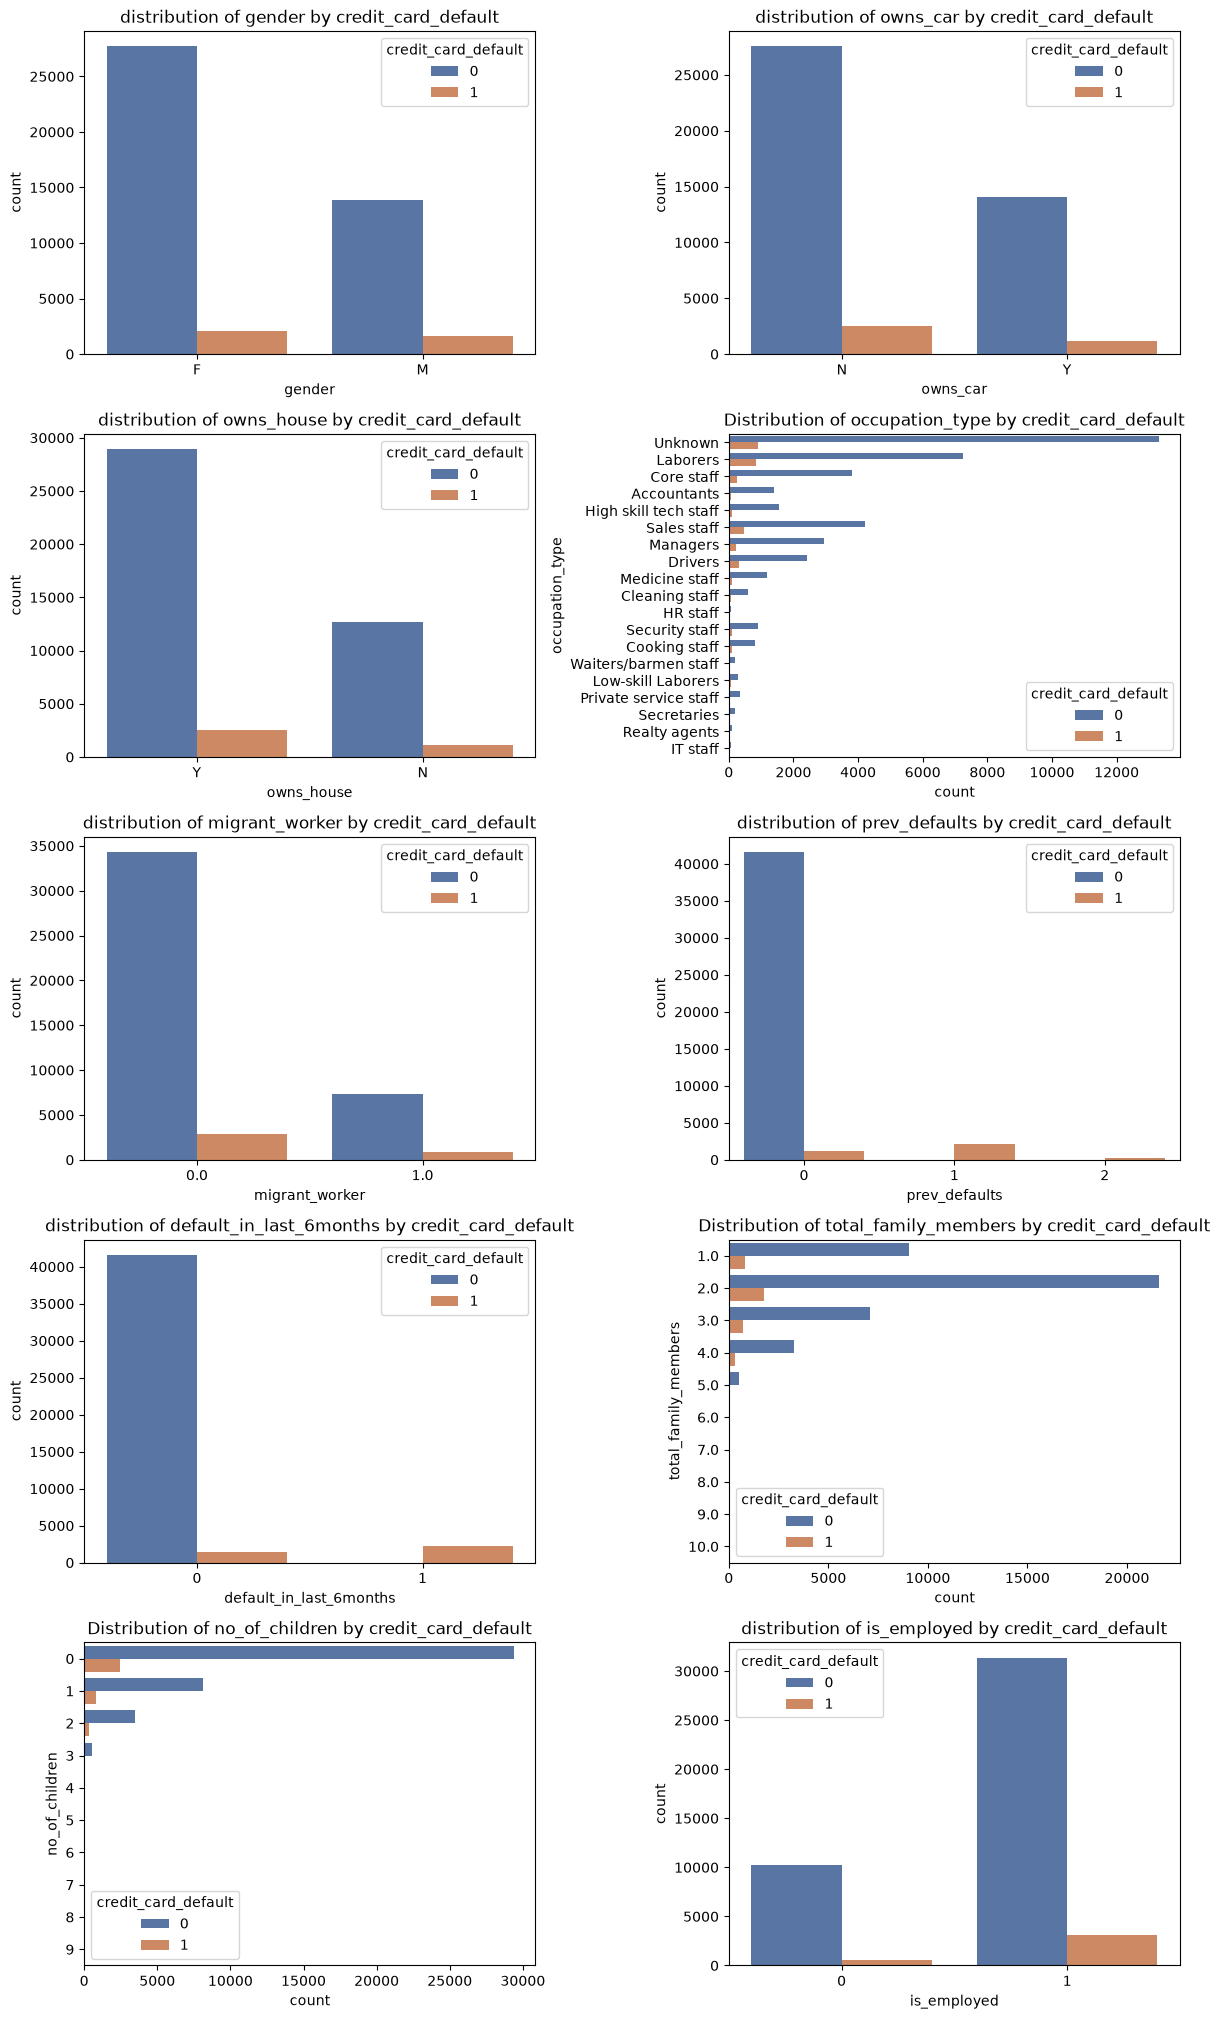

In [ ]:
plt.figure(figsize=(12,4*len(cat_col)))
for i,col in enumerate(cat_col):
    display((pd.crosstab(df[col],df[target],normalize="index")*100).T)
    plt.subplot(len(cat_col),2,i+1)
    if len(df[col].unique())>8:
        sns.countplot(data=df, y = col, hue = target, palette="deep")
        plt.title(f"Distribution of {col} by {target}")
    else:
        sns.countplot(data=df, x = col, hue=target, palette="deep")
        plt.title(f"distribution of {col} by {target}")
plt.tight_layout()
plt.show()

### Observations

- **Gender:** Male customers have a **higher default rate (~10.3%)** than female customers (~7.0%), indicating gender may have predictive power. The single `XNA` record can be ignored.

- **Owns Car:** Customers **without a car** show a slightly higher default rate (~8.45%) than those owning a car (~7.47%), suggesting a weak relationship with the target.

- **Owns House:** Default rates are almost identical for homeowners and non-homeowners (~8%), indicating this feature has limited predictive power.

- **Occupation Type:** Default rates vary noticeably across occupations. **Low-skill laborers (~15.8%)**, **Drivers (~11.7%)**, and **Cooking staff (~11.3%)** have relatively higher default rates, whereas **IT staff (~3.1%)** and **Secretaries (~4.1%)** have the lowest.

- **Migrant Worker:** Migrant workers have a slightly higher default rate (~10.1%) than non-migrant workers (~7.7%), suggesting a weak association with the target.

- **Previous Defaults:** Customers with **one or more previous defaults** have a **100% default rate** in the dataset, making this an extremely strong predictor of the target.

- **Default in Last 6 Months:** Customers who defaulted in the **last six months** also exhibit a **100% default rate**, making this one of the strongest predictive features.

- **Total Family Members:** Customers with **1–5 family members** have similar default rates (~7–9%). Categories with **6 or more members** contain very few observations, so their default rates are not reliable.

- **Number of Children:** Customers with **0–3 children** have comparable default rates (~7–9%). Categories with **4 or more children** contain very few observations, so any observed default rates should not be interpreted.

target VS categorical features

age


,count,mean,std,min,25%,50%,75%,max
credit_card_default,,,,,,,,
0,41580.0,38.995863,9.540655,23.0,31.0,39.0,47.0,55.0
1,3675.0,38.946395,9.574713,23.0,31.0,39.0,47.0,55.0


net_yearly_income


,count,mean,std,min,25%,50%,75%,max
credit_card_default,,,,,,,,
0,41580.0,198467.226865,1.183840e+05,28532.17,126577.50,172097.37,242071.830,4.433825e+06
1,3675.0,226674.599061,2.321034e+06,27170.61,124277.27,168174.78,225311.385,1.407590e+08


no_of_days_employed


...

,count,mean,std,min,25%,50%,75%,max
credit_card_default,,,,,,,,
0,41580.0,49.409452,28.859096,0.0,24.0,49.0,75.0,99.0
1,3675.0,84.529796,8.645178,70.0,77.0,84.0,92.0,99.0


credit_score


,count,mean,std,min,25%,50%,75%,max
credit_card_default,,,,,,,,
0,41580.0,799.097811,86.510821,650.0,724.0,799.0,874.0,949.0
1,3675.0,598.952925,56.862637,500.0,550.0,599.0,647.5,699.0


years_experienced


,count,mean,std,min,25%,50%,75%,max
credit_card_default,,,,,,,,
0,41580.0,4.363984,5.175420,0.0,0.270,2.75,6.520,38.96
1,3675.0,3.810414,4.235275,0.0,0.765,2.54,5.305,34.45


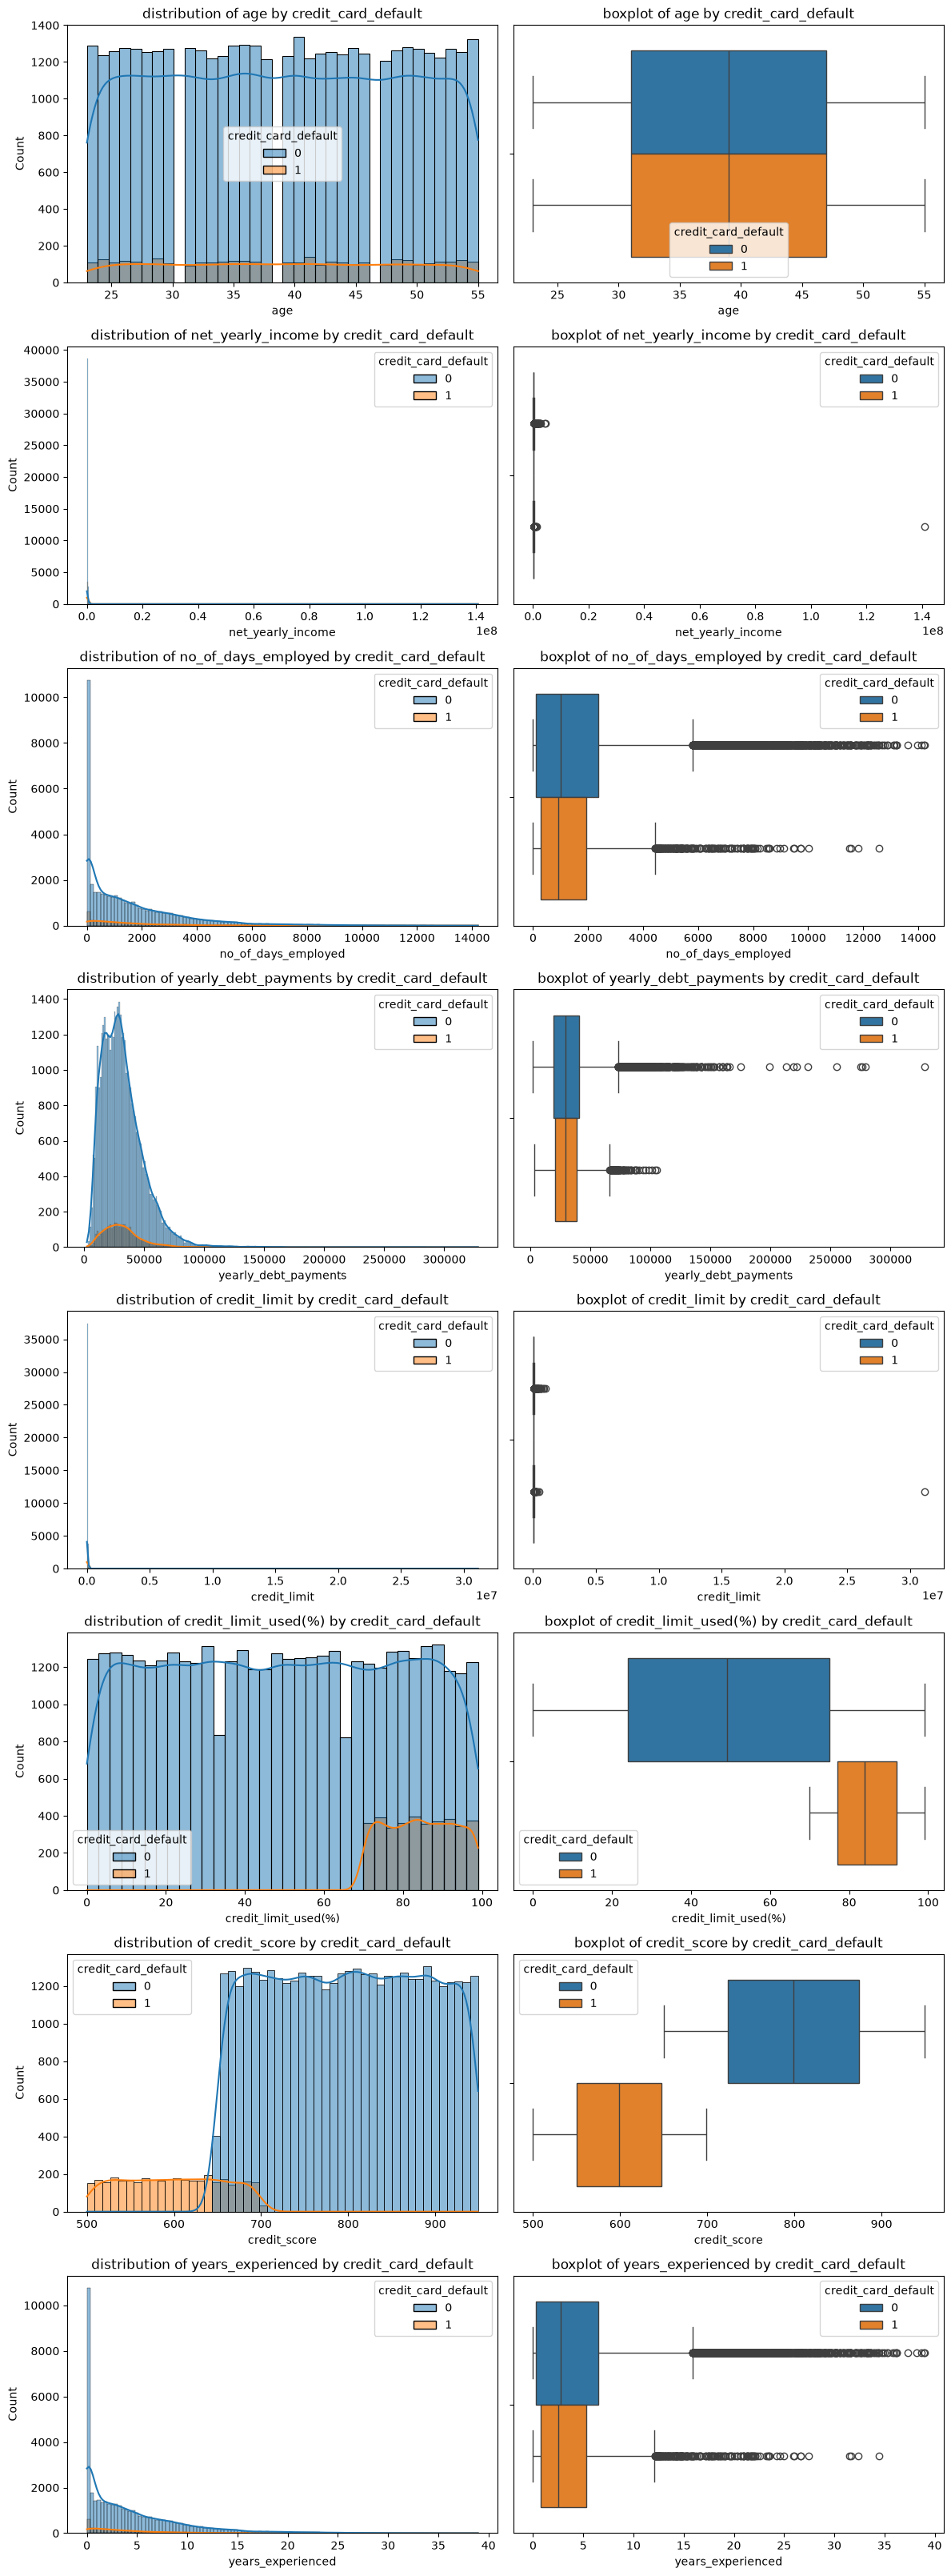

In [ ]:
plt.figure(figsize=(12,8*len(num_col)))
for i,col in enumerate(num_col):
    print(col)
    display((df.groupby(target)[col].describe()))
    plt.subplot(len(2*num_col),2,(2*i)+1)
    sns.histplot(data=df, x=col,hue=target,kde=True)
    plt.title(f"distribution of {col} by {target}")
    plt.subplot(2*len(num_col),2,2*(i+1))
    sns.boxplot(data=df, x=col,hue=target)
    plt.title(f"boxplot of {col} by {target}")
plt.tight_layout()
plt.show()

### Observations

- **Age:** The age distribution is almost identical for both classes (median = 39 years), indicating **very weak predictive power**.

- **Net Yearly Income:** Defaulters have a slightly lower median income than non-defaulters, but the distributions largely overlap, suggesting **limited predictive ability**.

- **No. of Days Employed:** Defaulters generally have **fewer employment days** than non-defaulters (median: 1475 vs. 2314 days), indicating a moderate relationship with default risk. The extreme value (365252) is present in both classes and should be handled separately.

- **Yearly Debt Payments:** Both classes have nearly identical distributions and median debt payments, indicating **little discrimination** between defaulters and non-defaulters.

- **Credit Limit:** Defaulters have a marginally lower credit limit than non-defaulters, but the distributions overlap considerably, suggesting **weak predictive power**.

- **Credit Limit Used (%):** Defaulters consistently exhibit **much higher credit utilization** (median ≈84%) than non-defaulters (median ≈49%), making this one of the **strongest predictive features**.

- **Credit Score:** Defaulters have **substantially lower credit scores** (median ≈599) than non-defaulters (median ≈799), with clear separation between the two distributions, making this the **most powerful predictor** in the dataset.

# Multivariate Analysis

In [ ]:
df.columns.tolist()

['age',
 'gender',
 'owns_car',
 'owns_house',
 'no_of_children',
 'net_yearly_income',
 'no_of_days_employed',
 'occupation_type',
 'total_family_members',
 'migrant_worker',
 'yearly_debt_payments',
 'credit_limit',
 'credit_limit_used(%)',
 'credit_score',
 'prev_defaults',
 'default_in_last_6months',
 'credit_card_default',
 'is_employed',
 'years_experienced',
 'log_net_yearly_income',
 'log_yearly_debt_payments',
 'log_credit_limit']

In [ ]:
numerical_cols = [
    "age",
    "no_of_children",
    "net_yearly_income",
    "no_of_days_employed",
    "total_family_members",
    "yearly_debt_payments",
    "credit_limit",
    "credit_limit_used(%)",
    "credit_score",
    "prev_defaults",
    "years_experienced",
    "log_net_yearly_income",
    "log_yearly_debt_payments",
    "migrant_worker",
    "log_credit_limit",
    "default_in_last_6months",
    "is_employed"

]

In [ ]:
categorical_cols = [
    "gender",
    "owns_car",
    "owns_house",
    "occupation_type"
]

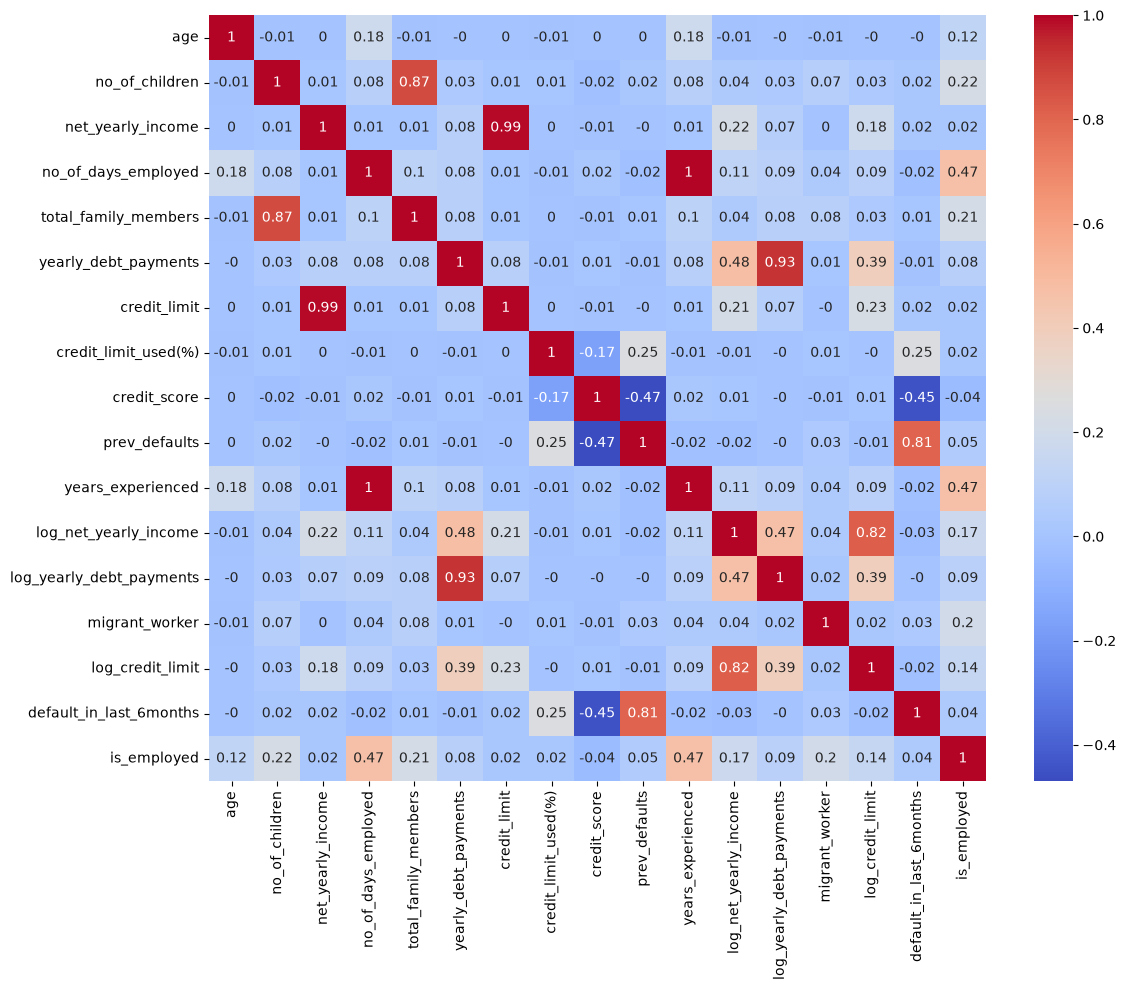

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(df[numerical_cols].corr().round(2),cmap="coolwarm", annot=True)
plt.tight_layout()
plt.show()

Encoding befor VIF

In [ ]:
df_e = df.copy()
te = TargetEncoder(cols=["occupation_type"])
df_e["occupation_type"] = te.fit_transform(df_e[["occupation_type"]],df_e["credit_card_default"])

ohe = OneHotEncoder(drop="first",sparse_output=False, handle_unknown="ignore")
encoded = ohe.fit_transform(df_e[["gender","owns_car","owns_house"]])
encoded_df = pd.DataFrame(encoded, columns= ohe.get_feature_names_out(["gender","owns_car","owns_house"]), index = df_e.index)
df_encoded = pd.concat([df_e.drop(columns= ["gender","owns_car","owns_house"]), encoded_df], axis=1)

In [ ]:
df_encoded.head()

,age,no_of_children,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),...,default_in_last_6months,credit_card_default,is_employed,years_experienced,log_net_yearly_income,log_yearly_debt_payments,log_credit_limit,gender_M,owns_car_Y,owns_house_Y
0,46,0,107934.04,612.0,0.064194,1.0,1.0,33070.28,18690.93,73,...,1,1,1,1.68,11.589285,10.406421,9.835847,0.0,0.0,1.0
1,29,0,109862.62,2771.0,0.104886,2.0,0.0,15329.53,37745.19,52,...,0,0,1,7.59,11.606995,9.637602,10.538640,1.0,0.0,1.0
2,37,0,230153.17,204.0,0.104886,2.0,0.0,48416.60,41598.36,43,...,0,0,1,0.56,12.346505,10.787619,10.635840,1.0,0.0,1.0
3,39,0,122325.82,0.0,0.059812,2.0,0.0,22574.36,32627.76,20,...,0,0,0,0.00,11.714452,10.024614,10.392949,0.0,0.0,1.0
4,46,0,387286.00,1459.0,0.059812,1.0,0.0,38282.95,52950.64,75,...,0,0,1,4.00,12.866921,10.552786,10.877134,1.0,1.0,1.0


VIF

In [ ]:
df_encoded.columns.tolist()

['age',
 'no_of_children',
 'net_yearly_income',
 'no_of_days_employed',
 'occupation_type',
 'total_family_members',
 'migrant_worker',
 'yearly_debt_payments',
 'credit_limit',
 'credit_limit_used(%)',
 'credit_score',
 'prev_defaults',
 'default_in_last_6months',
 'credit_card_default',
 'is_employed',
 'years_experienced',
 'log_net_yearly_income',
 'log_yearly_debt_payments',
 'log_credit_limit',
 'gender_M',
 'owns_car_Y',
 'owns_house_Y']

In [ ]:
columns = [
    "age",
    "no_of_children",
    "net_yearly_income",
    "no_of_days_employed",
    "occupation_type",
    "total_family_members",
    "migrant_worker",
    "yearly_debt_payments",
    "credit_limit",
    "credit_limit_used(%)",
    "credit_score",
    "prev_defaults",
    "default_in_last_6months",
    "is_employed",
    "years_experienced",
    "log_net_yearly_income",
    "log_yearly_debt_payments",
    "log_credit_limit",
    "gender_M",
    "owns_car_Y",
    "owns_house_Y"
]

In [ ]:
X = df_encoded[[
    "age",
    "no_of_children",
    "occupation_type",
    "total_family_members",
    "migrant_worker",
    "credit_limit_used(%)",
    "credit_score",
    "prev_defaults",
    "default_in_last_6months",
    "is_employed",
    "years_experienced",
    "log_net_yearly_income",
    "log_yearly_debt_payments",
    "log_credit_limit",
    "gender_M",
    "owns_car_Y",
    "owns_house_Y"
]]
X = sm.add_constant(X)
vif = pd.DataFrame({"feaures": X.columns, "VIF": [variance_inflation_factor(X.values ,i) for i in range(X.shape[1])]})
vif["VIF"] = vif["VIF"].round(2)
vif = vif.sort_values(by="VIF",ascending = False).reset_index(drop = True)

In [ ]:
display(vif)

,feaures,VIF
0,const,885.47
1,total_family_members,4.29
2,no_of_children,4.25
3,log_net_yearly_income,3.39
4,prev_defaults,3.08
5,default_in_last_6months,3.01
6,log_credit_limit,2.99
7,is_employed,1.60
8,years_experienced,1.34
9,log_yearly_debt_payments,1.32
